**Carga de los datasets que vamos a usar para esta libreta de ejemplos**

In [1]:
# MUY IMPORTANTE: SI DECIDES EJECUTAR ESTE NOTEBOOK EN VSCODE, EN LUGAR DE GOOGLE COLAB,
# DEBERÁS DESCOMENTAR ESTAS DOS INSTRUCCIONES PARA EVITAR ERRORES:

#import ssl

#ssl._create_default_https_context = ssl._create_unverified_context


In [2]:
import pandas as pd

# Cargar datasets desde el repositorio
startups_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/50_Startups.csv")
housing_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/housing.csv")
mall_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/Mall_Customers.csv")


**Ejemplos de gráficos de visualización con Matplotlib**

In [3]:
import matplotlib.pyplot as plt
import numpy as np

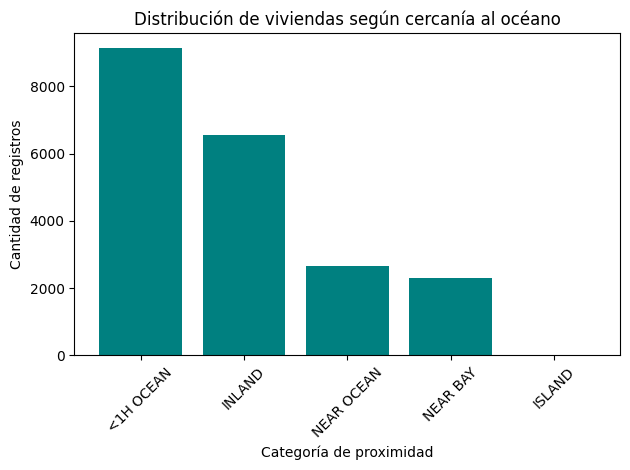

In [4]:
# Gráfico de barras con 'ocean_proximity'
counts = housing_df['ocean_proximity'].value_counts()
plt.bar(counts.index, counts.values, color='teal')
plt.title('Distribución de viviendas según cercanía al océano')
plt.xlabel('Categoría de proximidad')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

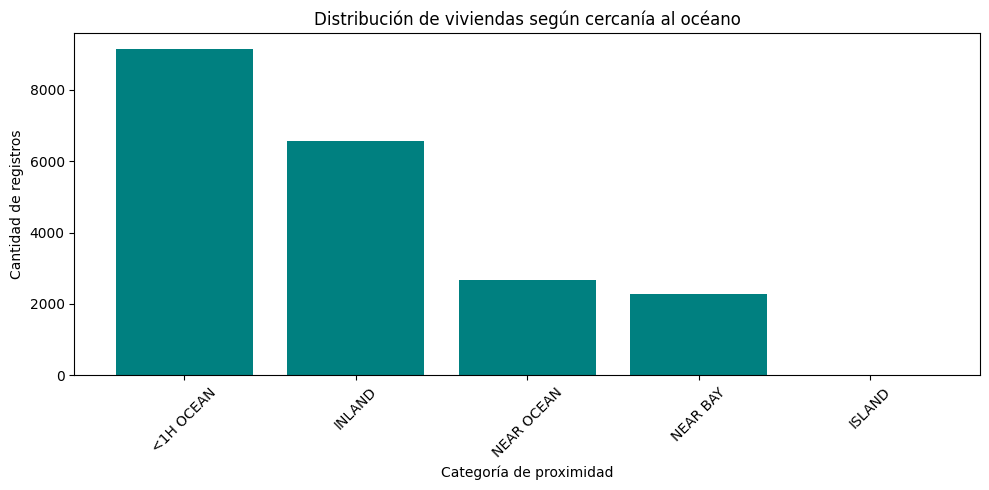

In [5]:
# Mismo gráfico pero redimensionado a medida
plt.figure(figsize=(10, 5))  # 10 de ancho, 5 de alto
counts = housing_df['ocean_proximity'].value_counts()
plt.bar(counts.index, counts.values, color='teal')
plt.title('Distribución de viviendas según cercanía al océano')
plt.xlabel('Categoría de proximidad')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

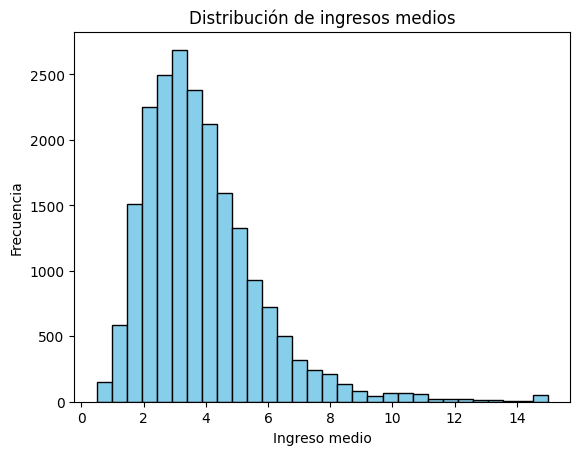

In [6]:
# 2. Histograma de columnas
plt.hist(housing_df['median_income'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de ingresos medios')
plt.xlabel('Ingreso medio')
plt.ylabel('Frecuencia')
plt.show()

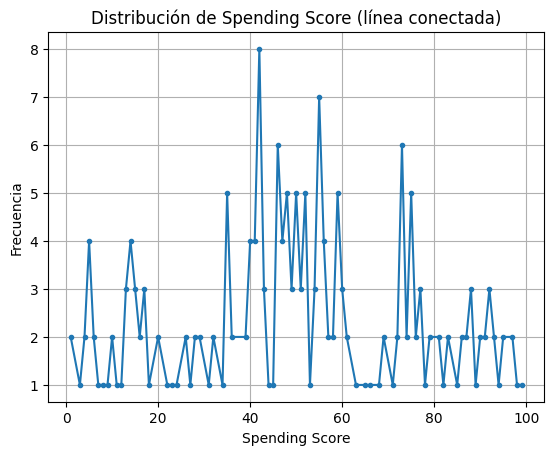

In [7]:
# Histograma de líneas suavizadas, simple y entendible
data = mall_df['Spending Score (1-100)'].dropna()

# Contar frecuencias directamente
counts = data.value_counts().sort_index() # En esta serie, los posibles valores del atributo pasan a ser los índices

# Dibujar una línea que conecta los puntos
plt.plot(counts.index, counts.values, marker='.', linestyle='-')
plt.title('Distribución de Spending Score (línea conectada)')
plt.xlabel('Spending Score')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


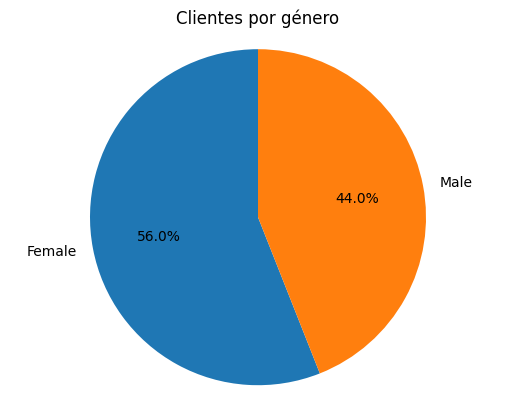

In [8]:
# Diagrama de sectores
gender_counts = mall_df['Gender'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Clientes por género')
plt.axis('equal')
plt.show()

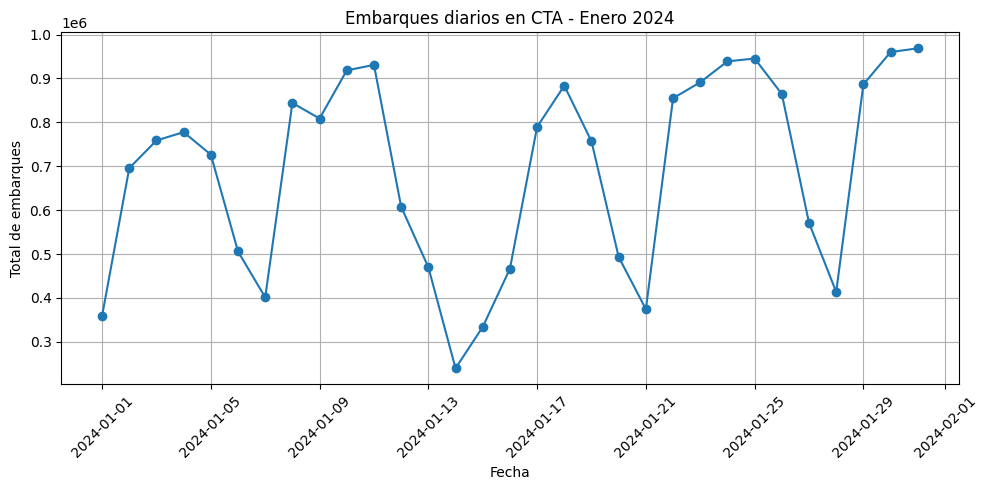

In [9]:
# Gráfico de líneas
# Cargar el dataset (es un dataset en abierto real, de la ciudad de Chicago)
url = "https://data.cityofchicago.org/api/views/6iiy-9s97/rows.csv?accessType=DOWNLOAD"
cta_df = pd.read_csv(url)

# Convertir la columna 'service_date' a tipo datetime
cta_df['service_date'] = pd.to_datetime(cta_df['service_date'])

# Filtrar datos para un período específico, por ejemplo, enero de 2024
start_date = '2024-01-01'
end_date = '2024-01-31'
mask = (cta_df['service_date'] >= start_date) & (cta_df['service_date'] <= end_date)
cta_january_2024 = cta_df.loc[mask]

# Ordenar por fecha
cta_january_2024 = cta_january_2024.sort_values('service_date')

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(cta_january_2024['service_date'], cta_january_2024['total_rides'], marker='o', linestyle='-')
plt.title('Embarques diarios en CTA - Enero 2024')
plt.xlabel('Fecha')
plt.ylabel('Total de embarques')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


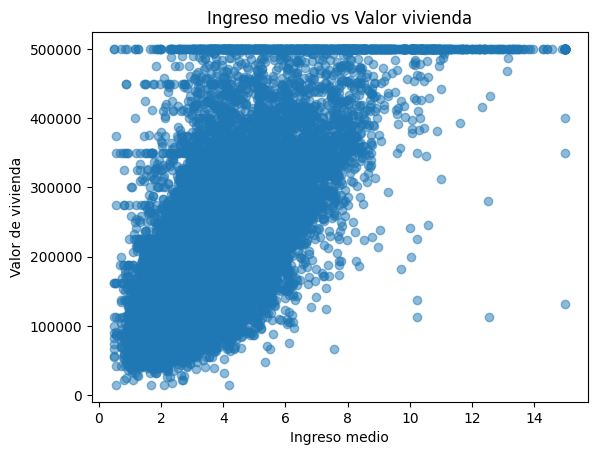

In [10]:
# 6. Scatter plot
plt.scatter(housing_df['median_income'], housing_df['median_house_value'], alpha=0.5)
plt.title('Ingreso medio vs Valor vivienda')
plt.xlabel('Ingreso medio')
plt.ylabel('Valor de vivienda')
plt.show()

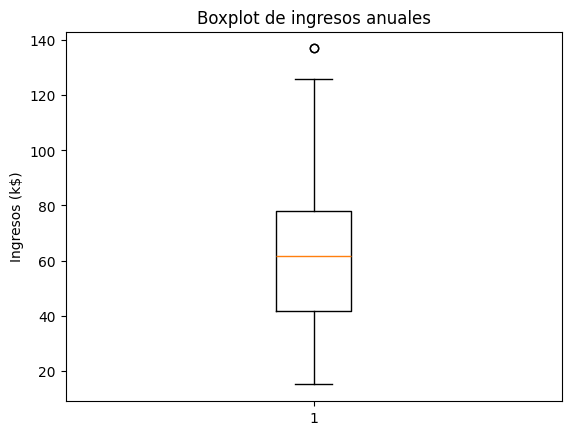

In [11]:
# 7. Box plot
plt.boxplot(mall_df['Annual Income (k$)'])
plt.title('Boxplot de ingresos anuales')
plt.ylabel('Ingresos (k$)')
plt.show()

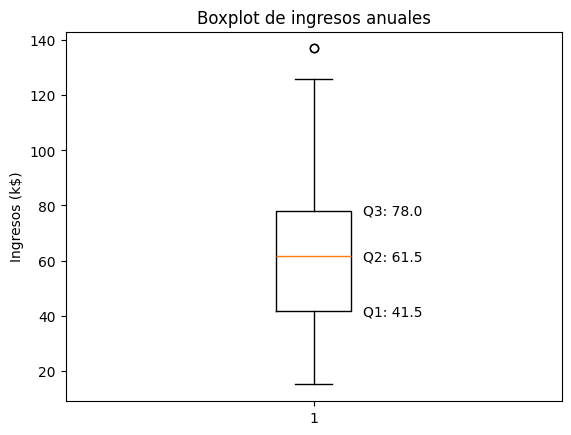

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
data = mall_df['Annual Income (k$)'].dropna()

# Crear boxplot
plt.boxplot(data, vert=True)
plt.title('Boxplot de ingresos anuales')
plt.ylabel('Ingresos (k$)')

# Calcular cuartiles
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)  # Mediana
q3 = np.percentile(data, 75)

# Anotar cuartiles en el gráfico
plt.text(1.1, q1, f'Q1: {q1:.1f}', va='center')
plt.text(1.1, q2, f'Q2: {q2:.1f}', va='center')
plt.text(1.1, q3, f'Q3: {q3:.1f}', va='center')

plt.show()


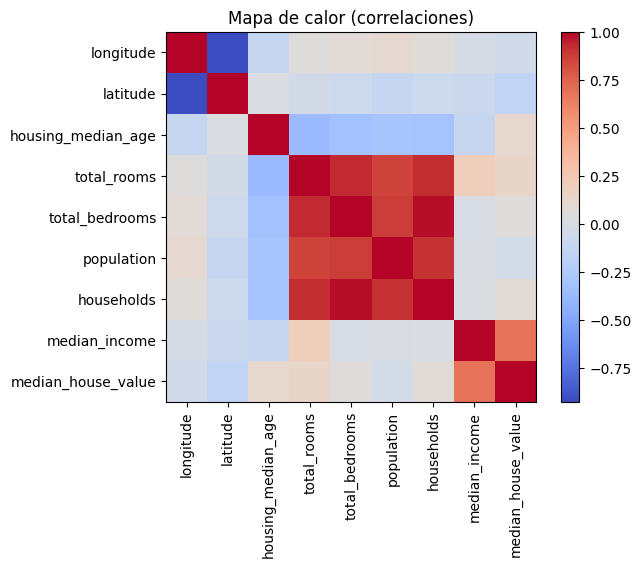

In [13]:
# 8. Mapa de calor 2D de correlaciones entre atributos numéricos
numeric_housing = housing_df.select_dtypes(include='number')
corr = numeric_housing.corr()
plt.imshow(corr, cmap='coolwarm', interpolation='none') # probar con interpolation='bilinear'
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Mapa de calor (correlaciones)')
plt.show()

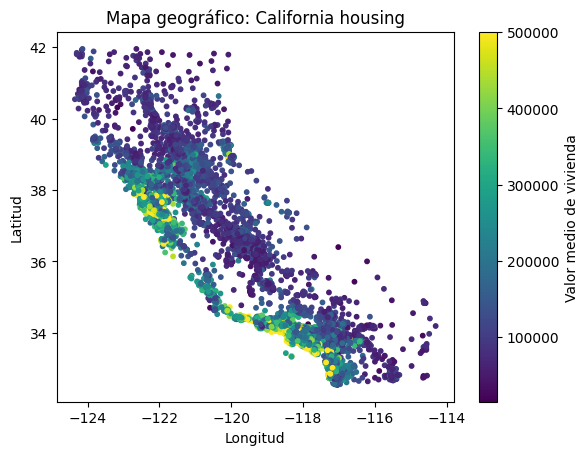

In [14]:
# 9. Mapa geográfico (scatter coloreado)
plt.scatter(housing_df['longitude'], housing_df['latitude'],
            c=housing_df['median_house_value'], cmap='viridis', s=10)
plt.colorbar(label='Valor medio de vivienda')
plt.title('Mapa geográfico: California housing')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

**EJEMPLOS CON SEABORN**

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset housing
housing_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/housing.csv")

# Dataset mall
mall_df = pd.read_csv("https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv")

# Dataset CTA Ridership (solo una muestra temporal)
cta_df = pd.read_csv("https://data.cityofchicago.org/api/views/6iiy-9s97/rows.csv?accessType=DOWNLOAD")


/tmp/ipykernel_7401/2327340534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=housing_df, x='ocean_proximity', palette='pastel')


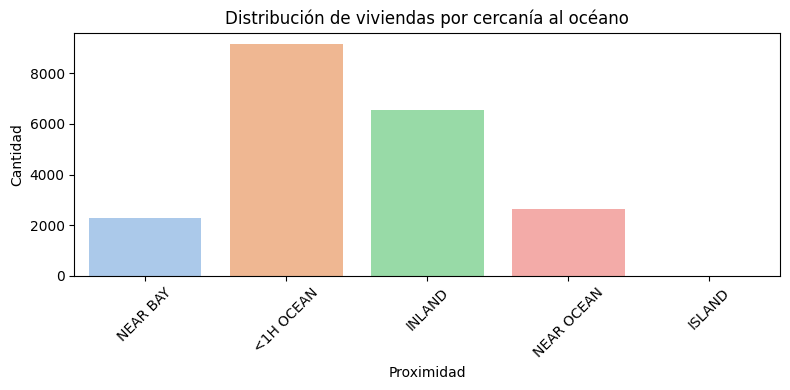

In [16]:
# Gráfico de barras
plt.figure(figsize=(8, 4))
sns.countplot(data=housing_df, x='ocean_proximity', palette='pastel')
plt.title('Distribución de viviendas por cercanía al océano')
plt.xlabel('Proximidad')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# countplot() de seaborn cuenta automáticamente las categorías y las grafica,
# sin necesidad de usar .value_counts(), y aplica una paleta de colores elegante
# por defecto. Reduce código y mejora apariencia.

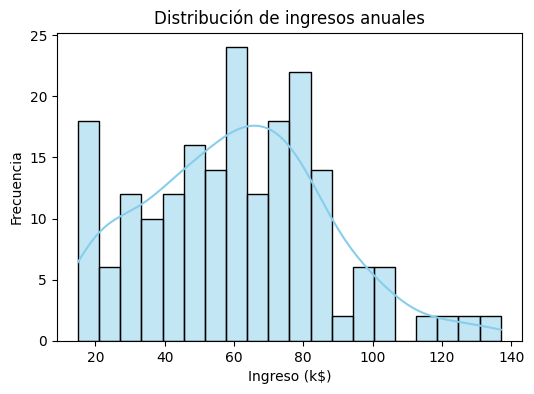

In [17]:
# Histograma de barras
plt.figure(figsize=(6, 4))
sns.histplot(mall_df['Annual Income (k$)'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de ingresos anuales')
plt.xlabel('Ingreso (k$)')
plt.ylabel('Frecuencia')
plt.show()

# Seaborn integra histogramas con opciones modernas como añadir suavizado (kde),
# elegir número de bins, y aplicar estilos automáticamente.
# En Matplotlib se requiere más código manual para lograr lo mismo.

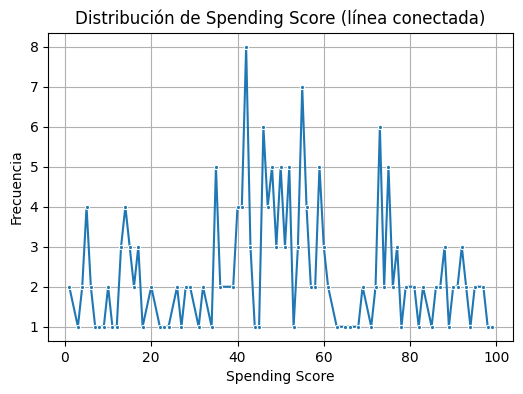

In [18]:
# Histograma de puntos
data = mall_df['Spending Score (1-100)'].dropna()
counts = data.value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.lineplot(x=counts.index, y=counts.values, marker='.')
plt.title('Distribución de Spending Score (línea conectada)')
plt.xlabel('Spending Score')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# lineplot() de seaborn permite conectar puntos de frecuencia de forma limpia,
# y aplica estilos automáticos (grid, bordes, ejes) sin necesidad de configurarlos
# uno a uno. También escala automáticamente el eje x.

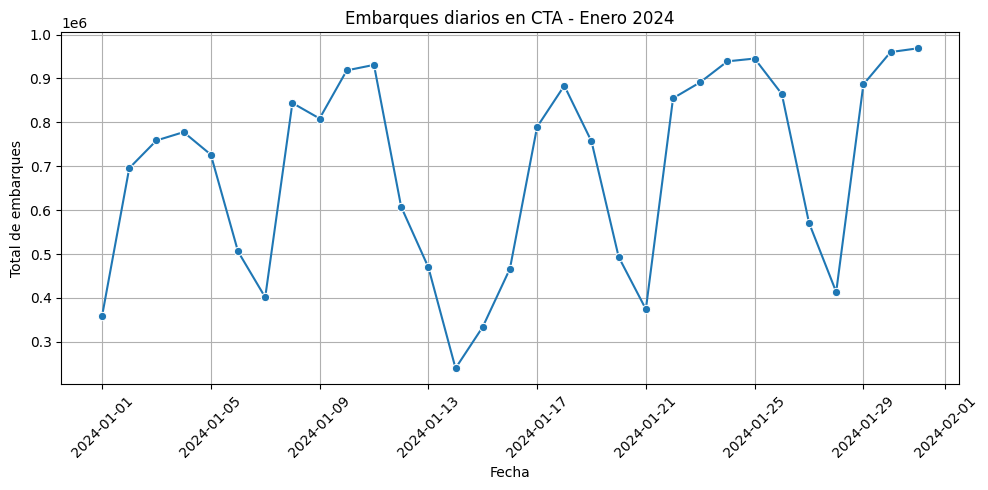

In [19]:
cta_df['service_date'] = pd.to_datetime(cta_df['service_date'])
cta_sample = cta_df[(cta_df['service_date'] >= '2024-01-01') & (cta_df['service_date'] <= '2024-01-31')]

# Gráfico de líneas
plt.figure(figsize=(10, 5))
sns.lineplot(data=cta_sample, x='service_date', y='total_rides', marker='o')
plt.title('Embarques diarios en CTA - Enero 2024')
plt.xlabel('Fecha')
plt.ylabel('Total de embarques')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Seaborn detecta automáticamente que service_date es temporal, formatea el eje x
# con fechas legibles y aplica un estilo consistente.
# Matplotlib requiere transformar manualmente las fechas y rotar etiquetas.

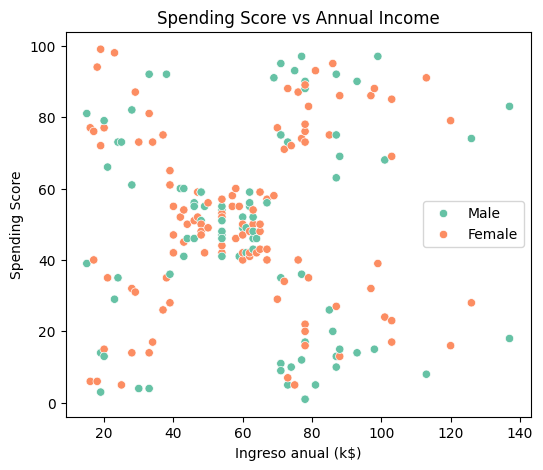

In [20]:
# Diagrama de dispersión (scatterplot)
plt.figure(figsize=(6, 5))
sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', palette='Set2')
plt.title('Spending Score vs Annual Income')
plt.xlabel('Ingreso anual (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

# Aqui seaborn permite agregar variables adicionales (como hue para color o size para tamaño) fácilmente,
# sin tener que construir leyendas ni escalas manuales.
# La leyenda se genera automáticamente.

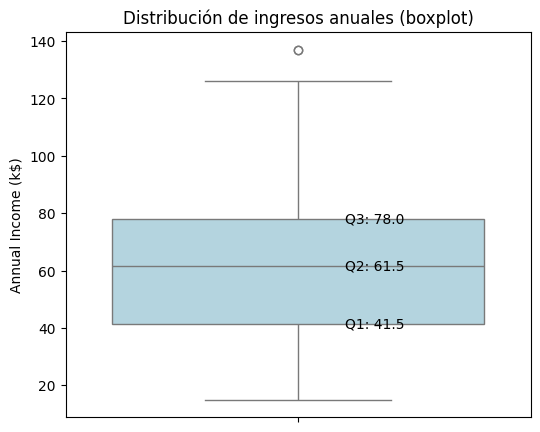

In [21]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=mall_df, y='Annual Income (k$)', color='lightblue')
plt.title('Distribución de ingresos anuales (boxplot)')

# Opcional: Calcular cuartiles
q1 = mall_df['Annual Income (k$)'].quantile(0.25)
q2 = mall_df['Annual Income (k$)'].quantile(0.50)
q3 = mall_df['Annual Income (k$)'].quantile(0.75)

# Opcional: Anotar los cuartiles
plt.text(0.1, q1, f'Q1: {q1:.1f}', va='center')
plt.text(0.1, q2, f'Q2: {q2:.1f}', va='center')
plt.text(0.1, q3, f'Q3: {q3:.1f}', va='center')

plt.show()

# boxplot() de seaborn estiliza automáticamente la visualización (colores, tamaño, ejes),
# y admite agrupación por categorías si se desea (ej. x='Gender').
# En Matplotlib se necesita mucho más código para lo mismo.

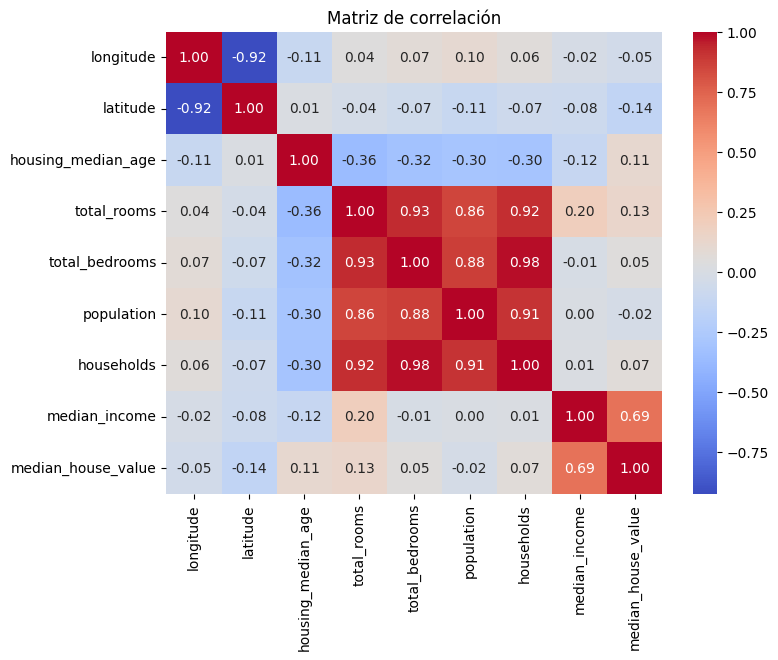

In [22]:
plt.figure(figsize=(8, 6))
corr = housing_df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

# heatmap() de seaborn, permite crear mapas de calor elegantes con
# anotaciones y color con una sola línea. En Matplotlib puro habría
# que iterar sobre los datos y construir texto y escalas de colores manualmente.

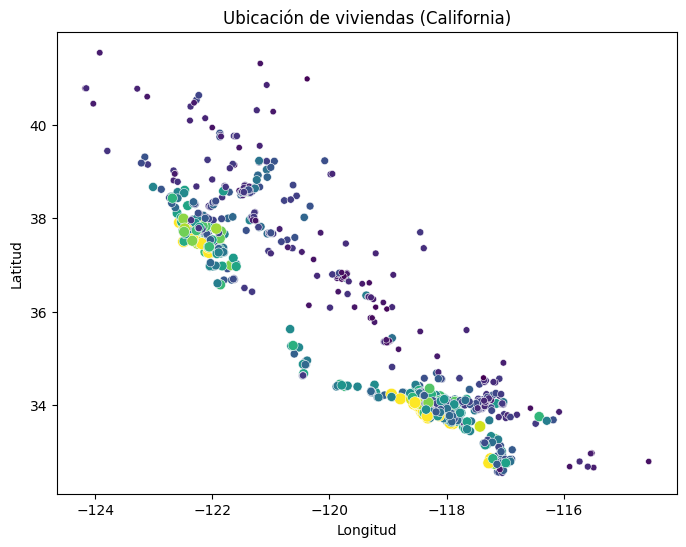

In [23]:
# Mapa con información geográfica
plt.figure(figsize=(8, 6))
sns.scatterplot(data=housing_df.sample(1000), x='longitude', y='latitude', hue='median_house_value', palette='viridis', size='median_house_value', legend=False)
plt.title('Ubicación de viviendas (California)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

# Seaborn permite representar datos geográficos codificados por color y tamaño fácilmente con hue y size.
# Ideal para mapas informativos aunque no sean mapas cartográficos completos.

**Gráficos combinados**

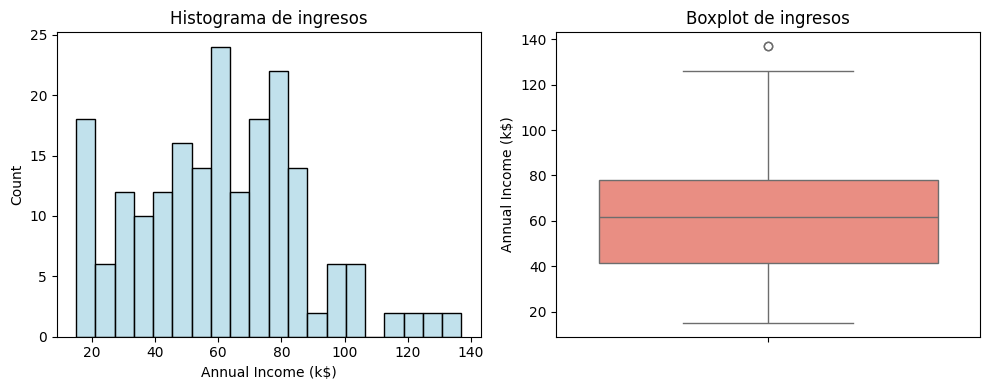

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Se crea una cuadrícula visual de 1 fila y 2 columnas, y se fija su tamaño.
# Se devuelven dos objetos: el "lienzo" (fig) y un array de subgráficos.

# Histograma
sns.histplot(mall_df['Annual Income (k$)'], bins=20, ax=axes[0], color='lightblue')
axes[0].set_title('Histograma de ingresos')

# Boxplot
sns.boxplot(data=mall_df, y='Annual Income (k$)', ax=axes[1], color='salmon')
axes[1].set_title('Boxplot de ingresos')

plt.tight_layout()
plt.show()


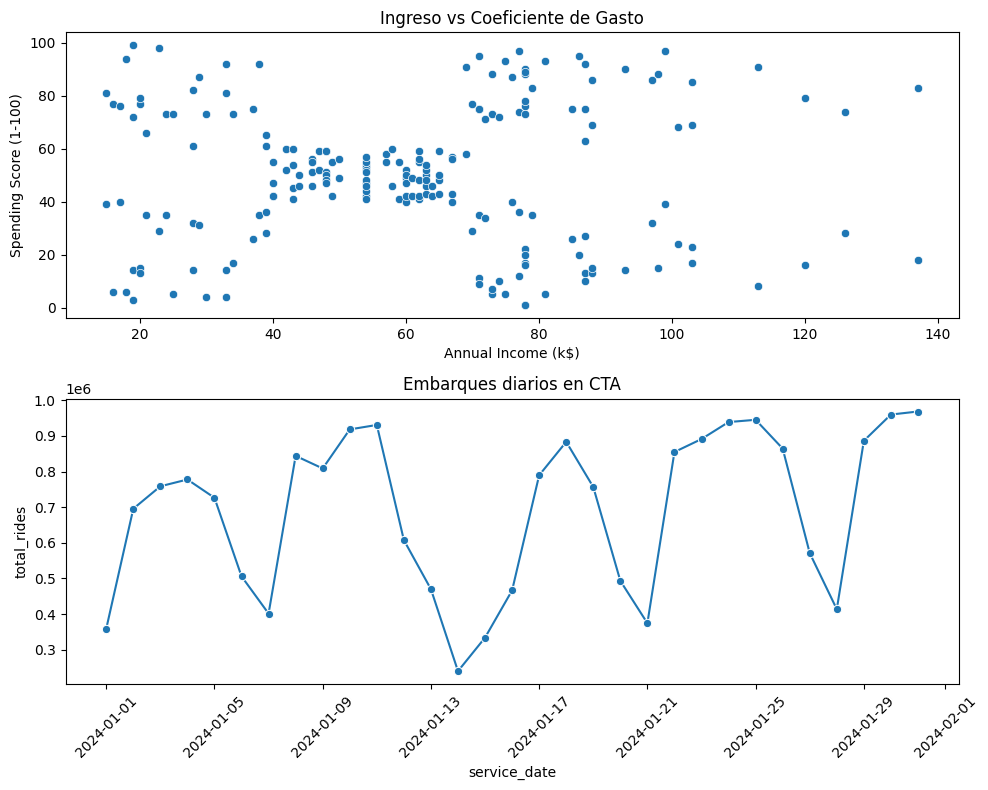

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Diagrama de Dispersión
sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)', ax=axes[0])
axes[0].set_title('Ingreso vs Coeficiente de Gasto')
# Gráfico de líneas
sns.lineplot(data=cta_sample, x='service_date', y='total_rides', marker='o', ax=axes[1])
axes[1].set_title('Embarques diarios en CTA')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout() # Ajuste automático de espacio para evitar solapamientos.
plt.show()


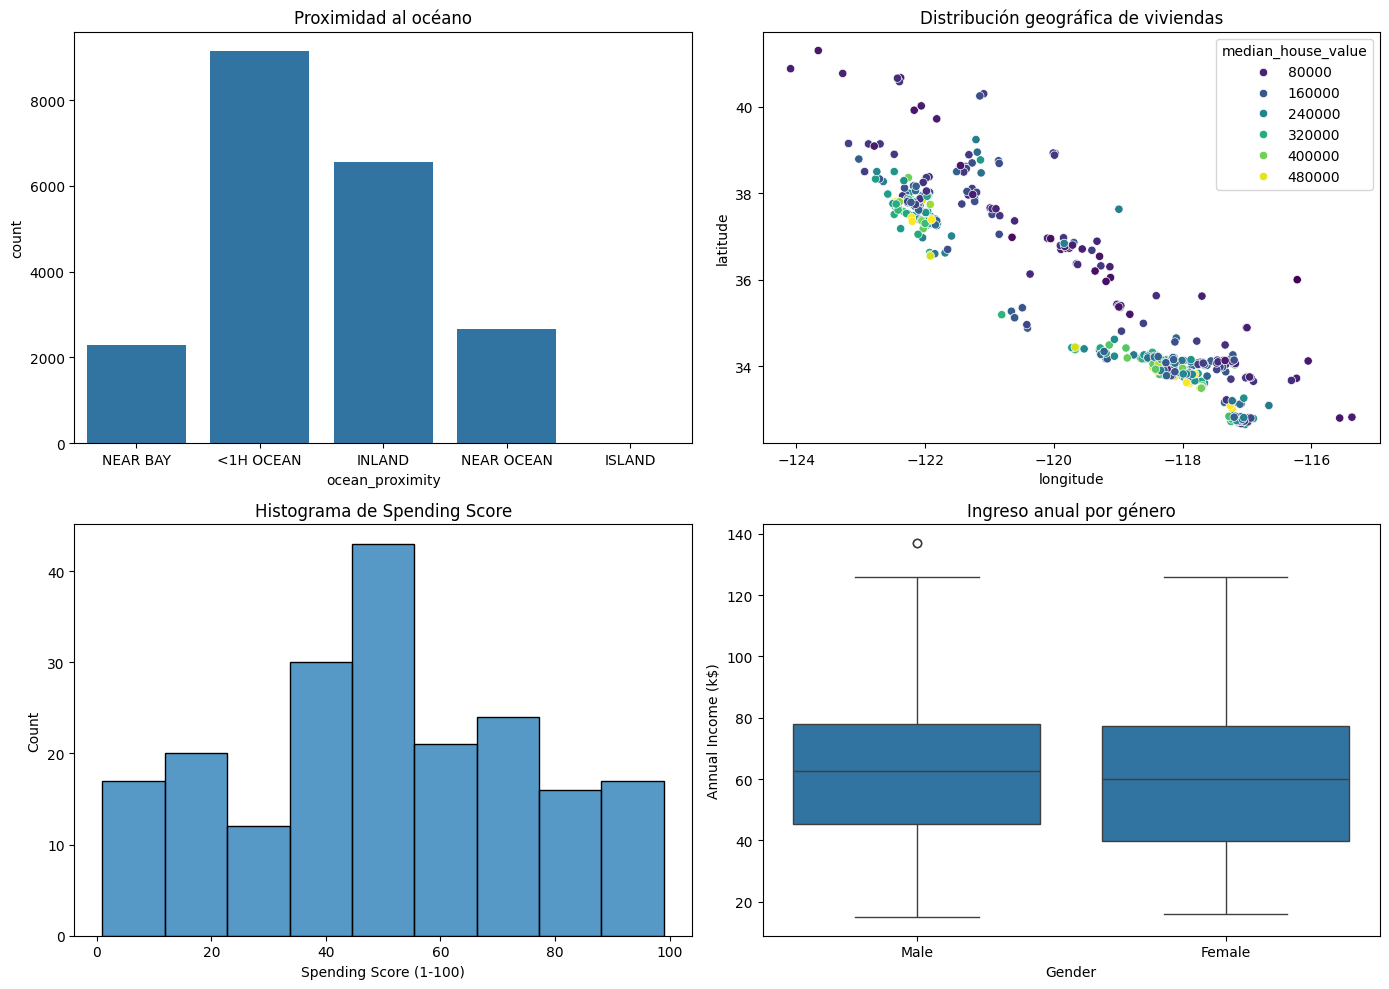

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Countplot
sns.countplot(data=housing_df, x='ocean_proximity', ax=axes[0, 0])
axes[0, 0].set_title('Proximidad al océano')

# Mapa dispersión
sns.scatterplot(data=housing_df.sample(500), x='longitude', y='latitude', hue='median_house_value', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Distribución geográfica de viviendas')

# Histograma
sns.histplot(mall_df['Spending Score (1-100)'], ax=axes[1, 0])
axes[1, 0].set_title('Histograma de Spending Score')

# Boxplot
sns.boxplot(data=mall_df, x='Gender', y='Annual Income (k$)', ax=axes[1, 1])
axes[1, 1].set_title('Ingreso anual por género')

plt.tight_layout()
plt.show()


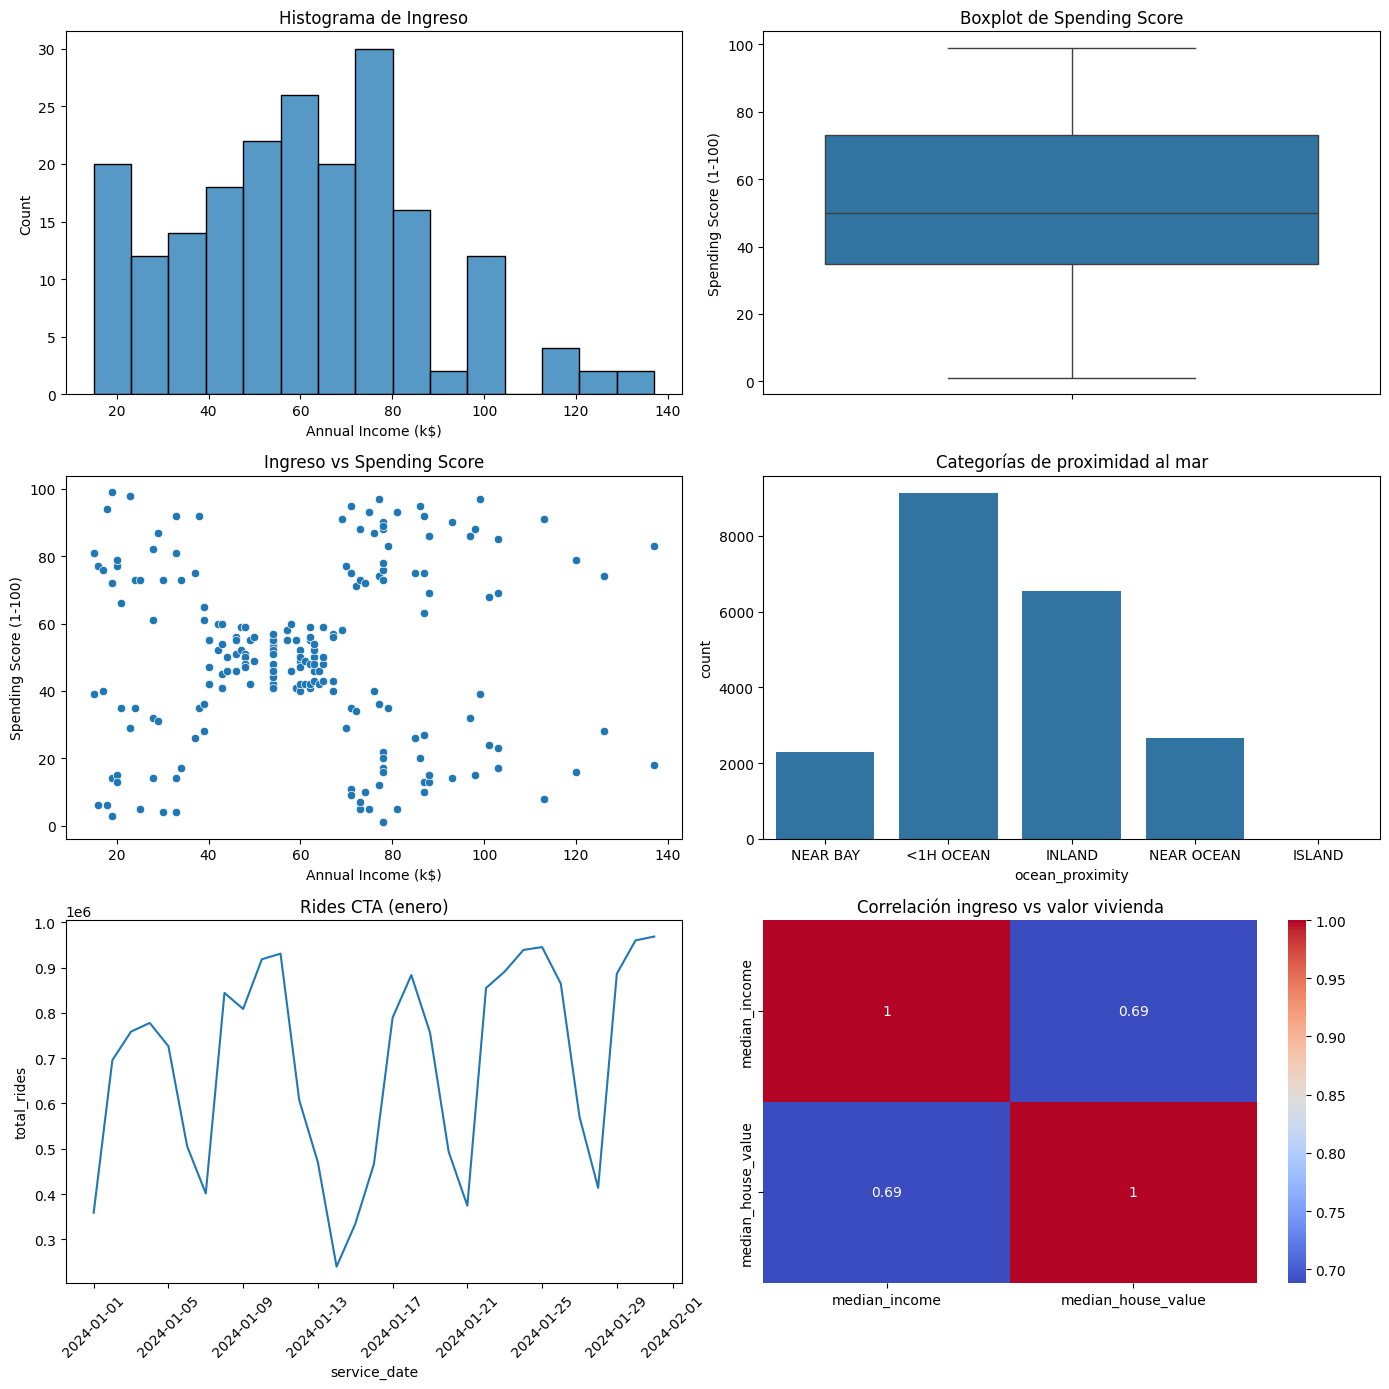

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

sns.histplot(mall_df['Annual Income (k$)'], bins=15, ax=axes[0, 0])
axes[0, 0].set_title('Histograma de Ingreso')

sns.boxplot(data=mall_df, y='Spending Score (1-100)', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot de Spending Score')

sns.scatterplot(data=mall_df, x='Annual Income (k$)', y='Spending Score (1-100)', ax=axes[1, 0])
axes[1, 0].set_title('Ingreso vs Spending Score')

sns.countplot(data=housing_df, x='ocean_proximity', ax=axes[1, 1])
axes[1, 1].set_title('Categorías de proximidad al mar')

sns.lineplot(data=cta_sample, x='service_date', y='total_rides', ax=axes[2, 0])
axes[2, 0].set_title('Rides CTA (enero)')
axes[2, 0].tick_params(axis='x', rotation=45)

corr = housing_df[['median_income', 'median_house_value']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[2, 1])
axes[2, 1].set_title('Correlación ingreso vs valor vivienda')

plt.tight_layout()
plt.show()


In [28]:
# Una comprobación rápida de los atributos del dataset CTA de Chicago (que contiene varias series temporales)
cta_df

,service_date,day_type,bus,rail_boardings,total_rides
0,2010-02-01,W,1091041,648428,1739469
1,2006-07-15,A,603018,412144,1015162
2,2017-08-26,A,487453,446049,933502
3,2007-12-25,U,249699,111582,361281
4,2005-07-08,W,950222,591325,1541547
...,...,...,...,...,...
9216,2026-03-27,W,543109,346088,889197
9217,2026-03-28,A,435694,352741,788435
9218,2026-03-29,U,352753,240934,593687
9219,2026-03-30,W,674656,424832,1099488


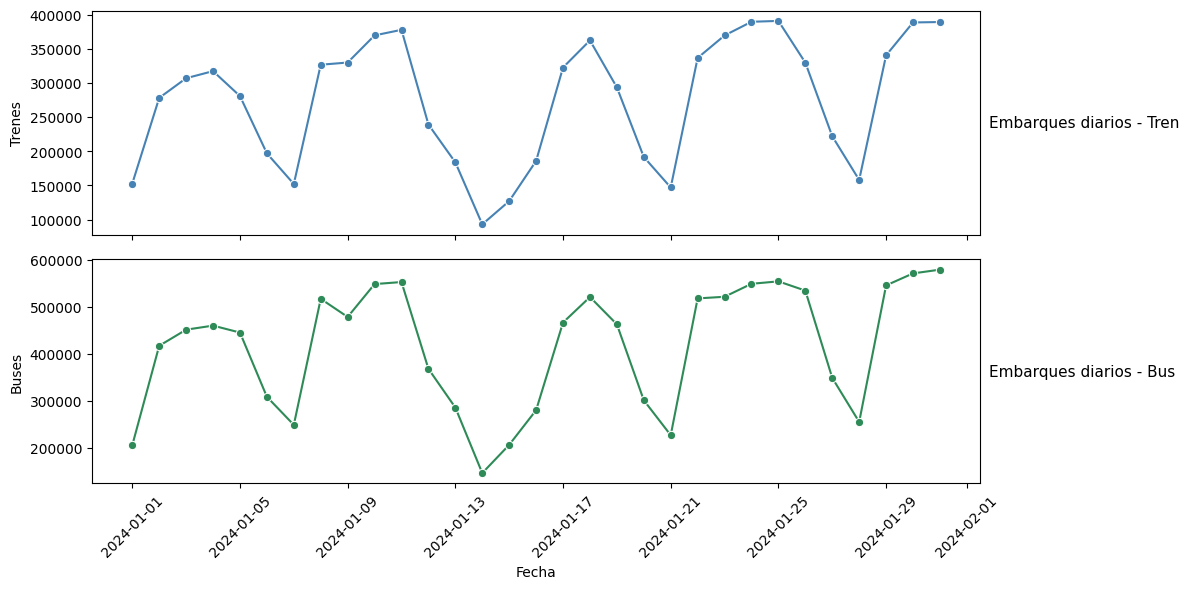

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegúrate de tener cargado el dataframe cta_df
cta_df['service_date'] = pd.to_datetime(cta_df['service_date'])

# Filtramos el mes de enero 2024
cta_sample = cta_df[
    (cta_df['service_date'] >= '2024-01-01') &
    (cta_df['service_date'] <= '2024-01-31')
]

# Creamos la figura con dos subplots que comparten eje X
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Gráfico de líneas para tren
sns.lineplot(data=cta_sample, x='service_date', y='rail_boardings', ax=ax1, marker='o', color='steelblue')
ax1.set_ylabel('Trenes')
ax1.text(1.01, 0.5, 'Embarques diarios - Tren', transform=ax1.transAxes,
         fontsize=11, va='center', ha='left')

# Gráfico de líneas para bus
sns.lineplot(data=cta_sample, x='service_date', y='bus', ax=ax2, marker='o', color='seagreen')
ax2.set_ylabel('Buses')
ax2.set_xlabel('Fecha')
ax2.tick_params(axis='x', rotation=45)
ax2.text(1.01, 0.5, 'Embarques diarios - Bus', transform=ax2.transAxes,
         fontsize=11, va='center', ha='left')

plt.tight_layout()
plt.show()
